In [12]:
import pandas as pd
import ast
from paretoset import paretoset
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

In [13]:
name = 'multiclass1'

In [14]:
deepseek_df = pd.read_csv(f'../LLMs/local_llms/deepseek/results/deepseekR1_ZS_{name}.csv')
gemma_df = pd.read_csv(f'../LLMs/local_llms/gemma/results/gemma_ZS_{name}.csv')
llama_df = pd.read_csv(f'../LLMs/local_llms/llama/results/llama_ZS_{name}.csv')
openai_df = pd.read_csv(f'../LLMs/api_llms/openai/results/openai_ZS_{name}.csv')
gemini_df = pd.read_csv(f'../LLMs/api_llms/gemini/results/gemini_ZS_{name}.csv')

sklearn_df = pd.read_csv(f'../sklearn_models_revised/results/results_sklearn_{name}.csv')
bert_df = pd.read_csv(f'../neural_nets/BERT_train/results/bert_{name}.csv')

lstm_df = pd.read_csv(f'../neural_nets/LSTM_FINAL/results/lstm_{name}.csv')

In [15]:
size = len(deepseek_df)
size

12284

In [16]:
def results_llm(df):
    error_count = len(df[df['prediction'] == 'error'])
    error_rate = error_count / len(df)

    print(f"Total predictions: {len(df)}")
    print(f"Error count: {error_count}")
    print(f"Error rate: {error_rate:.2%}")

    try:
        df = df[df['prediction_post_processed'] != 'error']
    except:
        df = df[df['prediction'] != 'error']

    y_true = df['label']

    try:
        y_pred = df['prediction_post_processed']
    except:
        y_pred = df['prediction']
        

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    try:
        mean_ram_usage = df['ram_usage'].mean()
        mean_vram_usage = df['vram_usage'].mean()
    except:
        mean_ram_usage = 0
        mean_vram_usage = 0
    
    try:
        mean_time = df['response_time'].mean()
    except:
        mean_time = df['request_time'].mean()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': mean_time
    }

    print(results)

    return results

In [17]:
print("DeepSeek results:")
results_deepseek = results_llm(deepseek_df)
print("\n")
print("Gemma results:")
results_gemma = results_llm(gemma_df)
print("\n")
print("Llama results:")
results_llama = results_llm(llama_df)
print("\n")
print("OpenAI results:")
results_openai = results_llm(openai_df)
print("\n")
print("Gemini results:")
results_gemini = results_llm(gemini_df)
print("\n")

DeepSeek results:
Total predictions: 12284
Error count: 102
Error rate: 0.83%
{'accuracy': 0.5480216713183386, 'precision': 0.5423823375730995, 'recall': 0.5806124855834272, 'f1_score': 0.5474301218309627, 'mean_ram_usage': np.float64(79.56509668465769), 'mean_vram_usage': np.float64(2157.70300443277), 'mean_response_time': np.float64(4.72710545889714)}


Gemma results:
Total predictions: 12284
Error count: 0
Error rate: 0.00%
{'accuracy': 0.5332953435363074, 'precision': 0.6359634843639178, 'recall': 0.6272506375510732, 'f1_score': 0.5153877517048785, 'mean_ram_usage': np.float64(102.15912817231765), 'mean_vram_usage': np.float64(5070.846466948877), 'mean_response_time': np.float64(2.3517418704837203)}


Llama results:
Total predictions: 12284
Error count: 1328
Error rate: 10.81%
{'accuracy': 0.4497991967871486, 'precision': 0.6155604444412215, 'recall': 0.5741489311107241, 'f1_score': 0.44180078509767196, 'mean_ram_usage': np.float64(88.88866153534593), 'mean_vram_usage': np.float64(

In [18]:
def results_sklearn(df):
    
    grouped = df.groupby(['vectorizer', 'model', 'params'])

    df['average_f1'] = df.filter(like='f1_class_').mean(axis=1)
    df['average_precision'] = df.filter(like='precision_class_').mean(axis=1)
    df['average_recall'] = df.filter(like='recall_class_').mean(axis=1)
    
    mean_f1 = grouped['average_f1'].mean().reset_index()
    
    best_model = mean_f1.loc[mean_f1['average_f1'].idxmax()]
    
    best_config_df = df[(df['vectorizer'] == best_model['vectorizer']) &
                        (df['model'] == best_model['model']) &
                        (df['params'] == best_model['params'])]
    
    accuracy = best_config_df['accuracy'].mean()
    f1 = best_config_df['average_f1'].mean()
    precision = best_config_df['average_precision'].mean()
    recall = best_config_df['average_recall'].mean()
    mean_ram_usage = best_config_df['peak_memory_prediction'].mean()
    mean_vram_usage = 0
    pred_time = best_config_df['prediction_time'].mean()

    std_accuracy = best_config_df['accuracy'].std()
    std_f1 = best_config_df['average_f1'].std()
    std_precision = best_config_df['average_precision'].std()
    std_recall = best_config_df['average_recall'].std()
    std_ram_usage = best_config_df['peak_memory_prediction'].std()
    std_vram_usage = 0
    std_pred_time = best_config_df['prediction_time'].std()


    results = {
        'name': best_model['model'],
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': pred_time / size
    }

    results_std = {
        'std_accuracy': std_accuracy,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1_score': std_f1,
        'std_mean_ram_usage': std_ram_usage,
        'std_mean_vram_usage': std_vram_usage,
        'std_mean_response_time': std_pred_time / size
    }    

    return results, results_std

In [19]:
results_sklearn_model = results_sklearn(sklearn_df)[0]

In [20]:
def results_bert(df):

    df['average_test_f1'] = df['test_f1s'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )
    df['average_test_precisions'] = df['test_precisions'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )
    df['average_test_recalls'] = df['test_recalls'].apply(
        lambda x: sum(ast.literal_eval(x)) / len(ast.literal_eval(x))
    )

    accuracy = df['test_acc'].mean()
    precision = df['average_test_precisions'].mean()
    recall = df['average_test_recalls'].mean()
    f1 = df['average_test_f1'].mean()
    mean_ram_usage = df['max_memory_usage_test'].mean()
    mean_vram_usage = df['max_vram_usage_test'].mean()
    mean_time = df['total_test_time'].mean()

    # now get standar deviation
    std_accuracy = df['test_acc'].std()
    std_precision = df['average_test_precisions'].std()
    std_recall = df['average_test_recalls'].std()
    std_f1 = df['average_test_f1'].std()
    std_ram_usage = df['max_memory_usage_test'].std()
    std_vram_usage = df['max_vram_usage_test'].std()
    std_time = df['total_test_time'].std()

    results = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'mean_ram_usage': mean_ram_usage,
        'mean_vram_usage': mean_vram_usage,
        'mean_response_time': mean_time / size
    }

    results_std = {
        'std_accuracy': std_accuracy,
        'std_precision': std_precision,
        'std_recall': std_recall,
        'std_f1_score': std_f1,
        'std_ram_usage': std_ram_usage,
        'std_vram_usage': std_vram_usage,
        'std_response_time': std_time / size
    }

    
    return results, results_std

results_bert_model = results_bert(bert_df)[0]
results_bert_model

{'accuracy': np.float64(0.6915771192879627),
 'precision': np.float64(0.6881331821028968),
 'recall': np.float64(0.7034410726775774),
 'f1_score': np.float64(0.6897571250251734),
 'mean_ram_usage': np.float64(1149.88671875),
 'mean_vram_usage': np.float64(1710.5709635416667),
 'mean_response_time': np.float64(0.010365064569087154)}

Models on the Pareto Frontier:
         model      time        f1
3  gpt-4o-mini  0.600125  0.722522
5         BERT  0.010365  0.689757
6          SVC  0.000440  0.596282


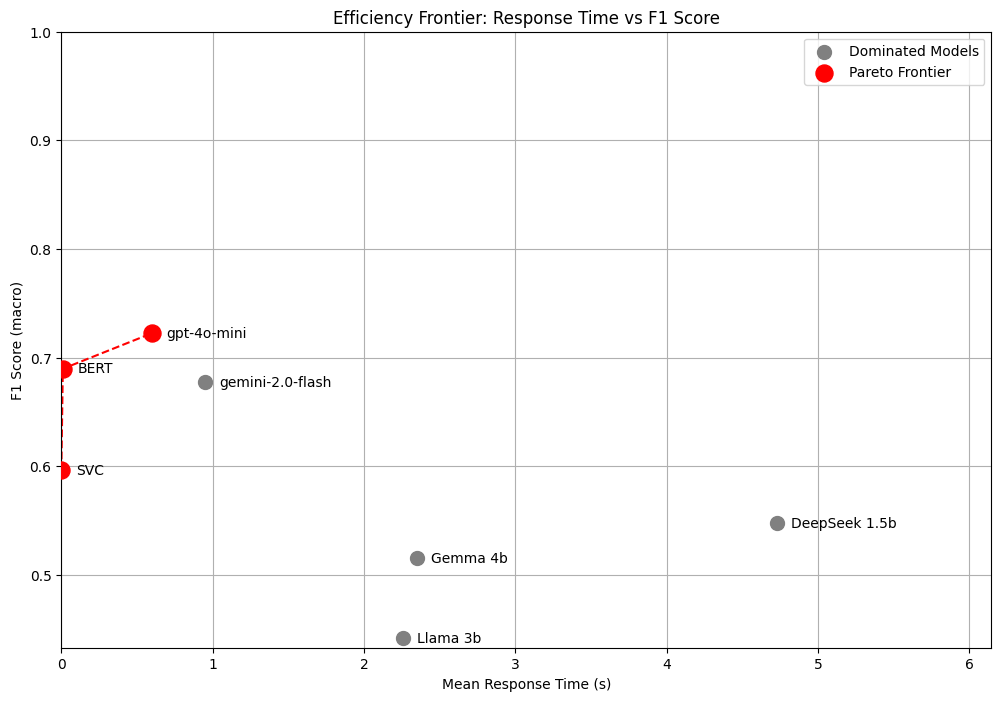

In [21]:
def plot_results(results):
    models = ['DeepSeek 1.5b', 'Gemma 4b', 'Llama 3b', 'gpt-4o-mini', 'gemini-2.0-flash', 'BERT', results[-1]['name']]
    mean_response_times = [result['mean_response_time'] for result in results]
    f1_scores = [result['f1_score'] for result in results]

    df = pd.DataFrame({
        'model': models,
        'time': mean_response_times,
        'f1': f1_scores
    })

    is_on_frontier = paretoset(df[['time', 'f1']], sense=['min', 'max'])
    
    frontier_df = df[is_on_frontier]
    
    print("Models on the Pareto Frontier:")
    print(frontier_df)

    plt.figure(figsize=(12, 8))
    
    plt.scatter(df['time'], df['f1'], color='grey', s=100, label='Dominated Models')
    
    plt.scatter(frontier_df['time'], frontier_df['f1'], color='red', s=150, zorder=5, label='Pareto Frontier')
    
    frontier_df = frontier_df.sort_values(by='time')
    plt.plot(frontier_df['time'], frontier_df['f1'], 'r--')

    offset = (max(mean_response_times) * 0.02)
    for i, row in df.iterrows():
        plt.text(row['time'] + offset, row['f1'], row['model'], ha='left', va='center')

    xlim_max = max(mean_response_times)
    plt.xlim(left=0, right=xlim_max + xlim_max * 0.3)
    plt.ylim(bottom=min(f1_scores) * 0.98, top=1.0)
    plt.xlabel('Mean Response Time (s)')
    plt.ylabel('F1 Score (macro)')
    plt.title('Efficiency Frontier: Response Time vs F1 Score')
    plt.legend()
    plt.grid(True)
    
    plt.show()

plot_results([results_deepseek, results_gemma, results_llama, results_openai, results_gemini, results_bert_model, results_sklearn_model])

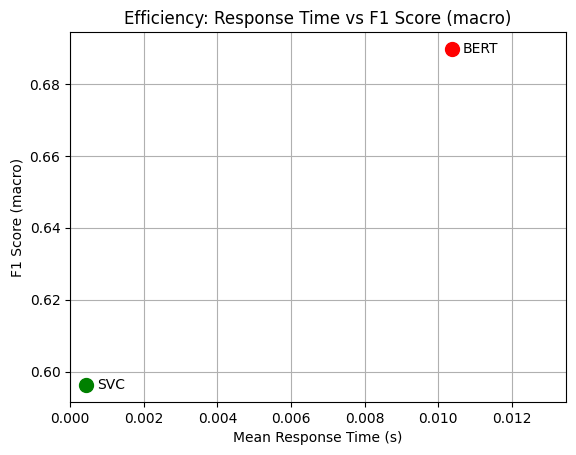

In [22]:
def plot_results(results):
    models = ['BERT', results[-1]['name']]
    colors = ['red', 'green']
    
    mean_response_times = [result['mean_response_time'] for result in results]
    f1_scores = [result['f1_score'] for result in results]
    
    offset = 0.0003
    
    for i in range(len(models)):
        plt.scatter(mean_response_times[i], f1_scores[i], color=colors[i], s=100)
        plt.text(mean_response_times[i] + offset, f1_scores[i], models[i], ha='left', va='center')
    
    xlim = max(mean_response_times)

    plt.xlim(left = 0, right = xlim + xlim * 0.3)
    plt.xlabel('Mean Response Time (s)')
    plt.ylabel('F1 Score (macro)')
    plt.title('Efficiency: Response Time vs F1 Score (macro)')
    plt.grid(True)
    
    plt.show()

plot_results([results_bert_model, results_sklearn_model])